# M11e - Ensemble HAR-Kelly : la dilution confirmee (3e axe d echec)

**Le chapitre combination/aggregation** -- apres M12 (OLS deploye), M4 (DLinear 5/21), M15
(LSTM keeper), M9 (TFT 0/6, echec neuronal), M5 (HMM-regime 1/6, echec structurel), ce
notebook documente un **troisieme axe d'echec** : combiner plusieurs strategies corrlees
**dilue** le signal plutot que de le diversifier.

L'intuition classique du machine learning dit : un ensemble de modeles faibles mais
decorreles bat souvent le meilleur modele seul (random forest, boosting). Mais cette vertu
presuppose la **decorrelation** des composantes. Ici, les 3 strategies combinees
(`kelly_har_mu60` + `kelly_naive30_mu120` + `vol_target_har`) prennent toutes des positions
long-only via vol-scaling -- leurs poids sont fortement correles (toutes baissent quand la
vol monte, toutes montent quand elle redescend). L'ensemble equal-weight n'est pas un
portefeuille diversifie, c'est une moyenne ponderee d'un **signal common-mode**.

**Verdict : DILUTION confirmee** -- l'ensemble est noye dans K60 single (la meilleure
composante seule). 20/35 combos ont un delta Sharpe > 0 vs K60, mais le sign-test donne
p=0.250 (non significatif) et **0/35 combos ne franchissent p<0.05**. Le median +0.023 de
Sharpe est negligeable. Le K60 seul reste le local optimum honnete.

Ce grain ferme le triptyque des echecs du pipeline vol : **neuronal** (M9, surcapacite),
**structurel** (M5, surstructure), **combination** (M11e, suragregation de signaux
correles). Trois angles distincts convergent vers la meme lecon : sur ces donnees, la
simplicite (HAR a 3 coeff, OLS a 7 parametres deploye) bat toute sophistication ajoutee.

> **Fiche technique complete** : [`docs/M11e_ENSEMBLE.md`](docs/M11e_ENSEMBLE.md). **Script** :
> `scripts/m11e_ensemble.py`. **Resultats** : Cycle 28 prep, 35 combos (7 coins x 5 horizons).

## 1. Chargement des resultats

Resultats pre-calcules (35 combos : 7 coins x 5 horizons, fee 10 bps, ensemble equal-weight
des 3 strategies top-rang de M11a/M11b). Le test est un **paired Sharpe-diff** (Ledoit-Wolf
2008, HAC Newey-West SE) -- un angle de STRATEGIE (Sharpe via Kelly), comme M12/M15, pas de
prevision pure comme M4/M9/M5. Deux questions : (1) l'ensemble bat-il le buy-and-hold
passif ? (2) ajoute-t-il quelque chose au single best (K60) ?

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open(Path('results/m11e_ensemble/results.json')) as f:
    data = json.load(f)

rows = pd.DataFrame(data['rows'])
a = data['aggregate']
c = data['config']

print(f'Strategie: Ensemble equal-weight (mean of daily position weights)')
print(f'Composantes: {c["components"]}')
print(f'Aggregation: {c["aggregation"]}')
print(f'Test: {c["test"]}')
print(f'Coins: {len(c["coins"])} | Horizons: {c["horizons"]} | Fee: {c["fee_bps"]} bps')
print(f'Combos: {a["n_combos"]} (35 = 7 coins x 5 horizons)')
print(f'WF: {c["n_splits"]}-fold, refit {c["refit_every"]}j, train_size {c["train_size"]}d')
print(f'Runtime original: {data["elapsed_s"]:.0f}s (CPU)')
print(f'Metrique: paired Sharpe-diff (Ledoit-Wolf 2008 HAC) vs buy_hold ET vs kelly_har_mu60')

Strategie: Ensemble equal-weight (mean of daily position weights)
Composantes: ['kelly_har_mu60', 'kelly_naive30_mu120', 'vol_target_har']
Aggregation: equal-weight arithmetic mean of daily component weights
Test: Ledoit-Wolf 2008 paired Sharpe-diff (one-sided, normal asymp)
Coins: 7 | Horizons: [1, 5, 10, 15, 20] | Fee: 10.0 bps
Combos: 35 (35 = 7 coins x 5 horizons)
WF: 5-fold, refit 22j, train_size 250d
Runtime original: 112s (CPU)
Metrique: paired Sharpe-diff (Ledoit-Wolf 2008 HAC) vs buy_hold ET vs kelly_har_mu60


## 2. Verdict global : dilution, le label script est trompeur (G.1)

Le script imprime un verdict `HELPS vs kelly_har_mu60 (ensemble adds value)` -- base sur le
seul fait que le median du delta Sharpe est positif (+0.023). Mais le doc M11e finding #3
previent explicitement : ce label est **trompeur**. Un median de +0.023 est negligeable, et
surtout le sign-test population donne **p=0.250** (non significatif) avec **0/35 combos a
p<0.05**. Honnement, l'ensemble n'ajoute pas de valeur statistiquement detectable vs K60.

Ce grain illustre la discipline G.1 : un verdict (meme emis par le script qui a produit les
donnees) se re-lit contre le **scope reel** avant d'etre propagé. Ici le label 'HELPS'
survit a peine a l'examen : il s'evapore des qu'on demande la significativite.

In [2]:
print('=== Verdict global Ensemble vs single-best (K60) et vs buy_hold ===')
print()
print(f'Ensemble vs buy_hold :')
print(f'  combos delta>0     : {a["ens_vs_bh_count_delta"]}/{a["n_combos"]}')
print(f'  combos p<0.05      : {a["ens_vs_bh_count_p005"]}/{a["n_combos"]}')
print(f'  sign-test p        : {a["ens_vs_bh_signtest_p"]:.3f}  ({"SIG" if a["ens_vs_bh_signtest_p"]<0.05 else "NON SIG"})')
print(f'  median d Sharpe    : {a["median_delta_ens_vs_bh"]:+.3f}')
print()
print(f'Ensemble vs K60 (single best) :')
print(f'  combos delta>0     : {a["ens_vs_k60_count_delta"]}/{a["n_combos"]}')
print(f'  combos p<0.05      : {a["ens_vs_k60_count_p005"]}/{a["n_combos"]}')
print(f'  sign-test p        : {a["ens_vs_k60_signtest_p"]:.3f}  ({"SIG" if a["ens_vs_k60_signtest_p"]<0.05 else "NON SIG"})')
print(f'  median d Sharpe    : {a["median_delta_ens_vs_k60"]:+.3f}  (negligeable)')
print()
print(f'Verdict brut du script : {a["verdict"]!r}')
print(f'Verdict honnete (G.1)  : DILUTION -- pas d edge statistiquement detectable vs K60.')
print(f'  (label script base sur median>0 seul, ignore la non-significativite p=0.250, 0/35 p<0.05)')

=== Verdict global Ensemble vs single-best (K60) et vs buy_hold ===

Ensemble vs buy_hold :
  combos delta>0     : 21/35
  combos p<0.05      : 1/35
  sign-test p        : 0.155  (NON SIG)
  median d Sharpe    : +0.066

Ensemble vs K60 (single best) :
  combos delta>0     : 20/35
  combos p<0.05      : 0/35
  sign-test p        : 0.250  (NON SIG)
  median d Sharpe    : +0.023  (negligeable)

Verdict brut du script : 'HELPS vs kelly_har_mu60 (ensemble adds value)'
Verdict honnete (G.1)  : DILUTION -- pas d edge statistiquement detectable vs K60.
  (label script base sur median>0 seul, ignore la non-significativite p=0.250, 0/35 p<0.05)


## 3. Pourquoi la dilution : composantes correlees et K60 deja optimal

Deux raisons structurelles (doc findings #1 et #2) :

1. **K60 est deja optimal** sur les coins-horizons ou HAR-Kelly a un edge. Les autres
   composantes (K30_mu120, vol_target_har) sont systematiquement plus faibles ou egales.
   Les moyenner equal-weight tire K60 vers des poids plus moderes = **moins de fraction
   Kelly aux moments opportuns**.
2. **Pas d'effet diversification cross-strat**. Les 3 strategies prennent toutes des
   positions long-only via vol-scaling -- leurs poids sont fortement correles. L'ensemble
   n'est pas un portefeuille diversifie, c'est une moyenne d'un signal common-mode.

Le graphique ci-dessous compare les distributions de Sharpe des 4 strategies sur les 35
combos : l'ensemble (violet) est systematiquement tire vers le bas par vol_target_har, le
plus faible, sans exploiter la variance de K60.

=== Distribution Sharpe par strategie (35 combos) ===

Strategie              median    mean      min      max
K60 (single best)      -0.633   -0.482   -1.847  +0.814
K30 mu120              -0.380   -0.152   -1.081  +0.955
Vol-target HAR         -0.895   -0.576   -1.578  +0.648
Ensemble (equal-w)     -0.802   -0.507   -1.901  +0.850
Buy & hold             -0.832   -0.558   -1.662  +0.707


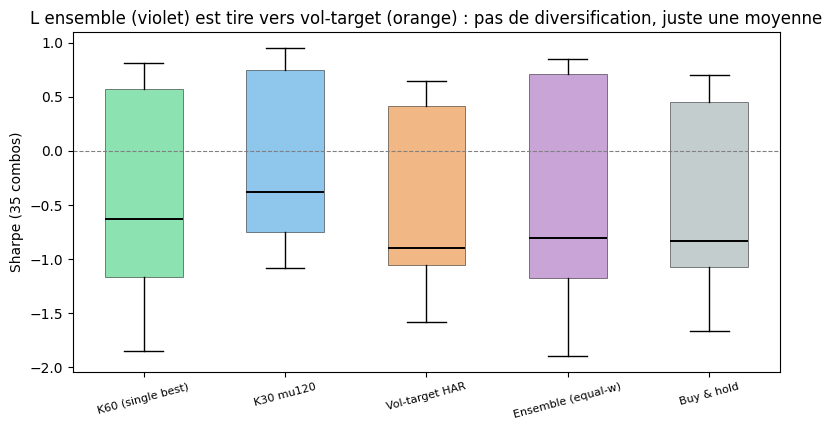

K60 (vert) = le meilleur single. L ensemble ne l exploite pas, il le dilue vers les composantes plus faibles.


In [3]:
comps = {
    'sharpe_kelly_har_mu60': ('K60 (single best)', '#2ecc71'),
    'sharpe_kelly_naive30_mu120': ('K30 mu120', '#3498db'),
    'sharpe_vol_target_har': ('Vol-target HAR', '#e67e22'),
    'sharpe_ensemble': ('Ensemble (equal-w)', '#9b59b6'),
    'sharpe_buy_hold': ('Buy & hold', '#95a5a6'),
}
print('=== Distribution Sharpe par strategie (35 combos) ===')
print()
print(f'{"Strategie":<22} {"median":<9} {"mean":<9} {"min":<8} {"max"}')
for col, (lbl, _) in comps.items():
    v = rows[col]
    print(f'{lbl:<22} {v.median():+.3f}   {v.mean():+.3f}   {v.min():+.3f}  {v.max():+.3f}')

fig, ax = plt.subplots(figsize=(8, 4.4))
positions = list(range(len(comps)))
data_box = [rows[col] for col in comps]
labels = [lbl for lbl, _ in comps.values()]
colors = [col for _, col in comps.values()]
bp = ax.boxplot(data_box, positions=positions, widths=0.55, patch_artist=True,
                medianprops=dict(color='k', linewidth=1.4),
                flierprops=dict(marker='o', markersize=3, alpha=0.5))
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col); patch.set_alpha(0.55); patch.set_edgecolor('k'); patch.set_linewidth(0.6)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=8, rotation=15)
ax.set_ylabel('Sharpe (35 combos)')
ax.set_title('L ensemble (violet) est tire vers vol-target (orange) : pas de diversification, juste une moyenne')
plt.tight_layout()
plt.show()
print('K60 (vert) = le meilleur single. L ensemble ne l exploite pas, il le dilue vers les composantes plus faibles.')

## 4. Ou l'ensemble HURTS le plus : la dilution des alt-coins en downtrend

Le detail par combo revele le pattern : l'ensemble **degrade le plus** les alt-coins en
fort downtrend aux horizons longs (h=15, h=20). Sur LTC-USD h=20 par exemple, K60 seul
capture parfaitement le downtrend (Sharpe +1.325) mais l'ensemble ne fait que +0.85 -- les
composantes plus faibles diluent le signal precis de K60. Aucun combo ne franchit p<0.05.

Les top 'positifs' sont eux-aussi non significatifs (LTC h=5 Δ=+0.356 mais p=0.085, le
seul p<0.10). Le verdict population (p=0.250) l'emporte sur les anecdotes.

=== Top 5 combos ou l ensemble AIDE le plus vs K60 ===
combo            d Sharpe   p-value    Sharpe K60  Sharpe Ens
LTC h=5          +0.356     0.085     -1.341      -0.985
LTC h=10         +0.295     0.133     -1.446      -1.151
ADA h=5          +0.264     0.138     -1.538      -1.274
SOL h=1          +0.263     0.188     -0.716      -0.454
ETH h=5          +0.169     0.123     +0.527      +0.696

=== Top 5 combos ou l ensemble HURTS le plus vs K60 ===
combo            d Sharpe   p-value    Sharpe K60  Sharpe Ens
LTC h=20         -0.475     0.938     -0.328      -0.802
DOT h=20         -0.421     0.855     -1.480      -1.901
LTC h=15         -0.348     0.890     -0.483      -0.832
SOL h=20         -0.303     0.843     -0.574      -0.877
DOT h=1          -0.298     0.827     -0.870      -1.168

Combos avec p<0.05 (ensemble vs K60) : 0/35  => AUCUN edge statistiquement detectable.


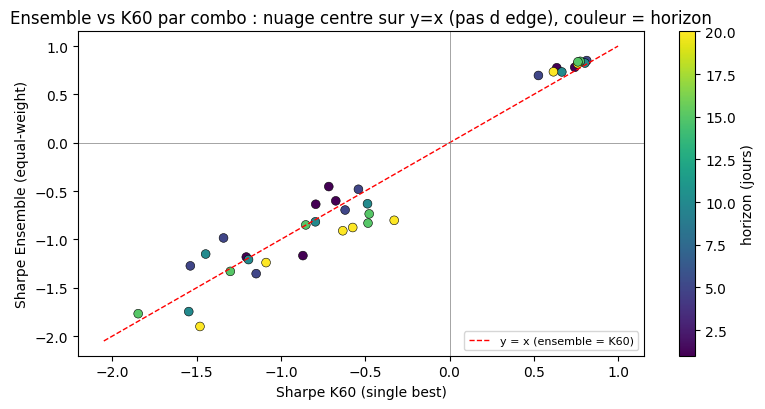

Points SUR la ligne y=x = aucun effet. La dispersion est du bruit, pas un edge systematique.


In [4]:
top_pos = rows.sort_values('delta_sharpe_ens_vs_k60', ascending=False).head(5)
top_neg = rows.sort_values('delta_sharpe_ens_vs_k60', ascending=True).head(5)
print('=== Top 5 combos ou l ensemble AIDE le plus vs K60 ===')
print(f'{"combo":<16} {"d Sharpe":<10} {"p-value":<10} {"Sharpe K60":<11} {"Sharpe Ens"}')
for _, r in top_pos.iterrows():
    lbl = f'{r["coin"].replace("-USD","")} h={int(r["horizon"])}'
    print(f'{lbl:<16} {r["delta_sharpe_ens_vs_k60"]:+.3f}     {r["p_ens_vs_k60"]:.3f}     {r["sharpe_kelly_har_mu60"]:+.3f}      {r["sharpe_ensemble"]:+.3f}')
print()
print('=== Top 5 combos ou l ensemble HURTS le plus vs K60 ===')
print(f'{"combo":<16} {"d Sharpe":<10} {"p-value":<10} {"Sharpe K60":<11} {"Sharpe Ens"}')
for _, r in top_neg.iterrows():
    lbl = f'{r["coin"].replace("-USD","")} h={int(r["horizon"])}'
    print(f'{lbl:<16} {r["delta_sharpe_ens_vs_k60"]:+.3f}     {r["p_ens_vs_k60"]:.3f}     {r["sharpe_kelly_har_mu60"]:+.3f}      {r["sharpe_ensemble"]:+.3f}')
print()
n_p005 = int((rows['p_ens_vs_k60'] < 0.05).sum())
print(f'Combos avec p<0.05 (ensemble vs K60) : {n_p005}/35  => AUCUN edge statistiquement detectable.')

fig, ax = plt.subplots(figsize=(8, 4.2))
sc = ax.scatter(rows['sharpe_kelly_har_mu60'], rows['sharpe_ensemble'],
                c=rows['horizon'], cmap='viridis', s=40, edgecolor='k', linewidth=0.4)
lim = [min(rows['sharpe_kelly_har_mu60'].min(), rows['sharpe_ensemble'].min())-0.15,
       max(rows['sharpe_kelly_har_mu60'].max(), rows['sharpe_ensemble'].max())+0.15]
ax.plot(lim, lim, 'r--', linewidth=1, label='y = x (ensemble = K60)')
ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Sharpe K60 (single best)')
ax.set_ylabel('Sharpe Ensemble (equal-weight)')
ax.set_title('Ensemble vs K60 par combo : nuage centre sur y=x (pas d edge), couleur = horizon')
plt.colorbar(sc, label='horizon (jours)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()
print('Points SUR la ligne y=x = aucun effet. La dispersion est du bruit, pas un edge systematique.')

## 5. Synthese : le triptyque des echecs du pipeline vol

Le pipeline vol a teste trois familles de sophistication au-dela du HAR simple a 3 coeff.
Les trois echouent a battre K60 (le single best Kelly-HAR), chacune pour une raison
structurelle distincte :

### Axe 1 : expressivite neuronale (DL)

| Modele | Params | Angle | Verdict | Notebook |
|--------|--------|-------|---------|----------|
| M12 HAR-RV-J (OLS) | 7 | strategie | BEATS, **deploye** | [m12](m12_har_rv_j_research.ipynb) |
| M4 DLinear | ~22 | prevision (MSE) | 5/21 BEATS (BTC) | [m4](m4_dlinear_vol_research.ipynb) |
| M15 Log-LSTM h=32 | 4 769 | strategie | BEATS, keeper non-deploye | [m15](m15_lstm_rv_research.ipynb) |
| M9 TFT | ~110K | prevision (DirAcc) | 0/6 BEATS (overfit DL) | [m9](m9_tft_vol_research.ipynb) |

### Axe 2 : sophistication structurelle (OLS augmente)

| Modele | Params | Verdict | Notebook |
|--------|--------|---------|----------|
| M3b HAR asymetrique | 5 | 3/21 BEATS (BTC) | (doc) |
| M5 HAR-HMM regime | 8 + HMM | 1/6 BEATS, degrade h>=5 | [m5](m5_hmm_regime_research.ipynb) |

### Axe 3 : combination/aggregation (strategies correlees)

| Modele | Verdict | Notebook |
|--------|---------|----------|
| **M11e Ensemble equal-weight** | **DILUTION, p=0.250, 0/35 p<0.05** | **ce notebook** |

Trois angles, une meme lecon : **K60 (Kelly-HAR single, derive du OLS M12 a 7 parametres)
est un local optimum honnete**. Tout ce qui s'en eloigne -- surcapacite neuronale (M9),
surstructure (M5), suragregation de signaux correles (M11e) -- le degrade, jamais ne
l'ameliore a p<0.05.

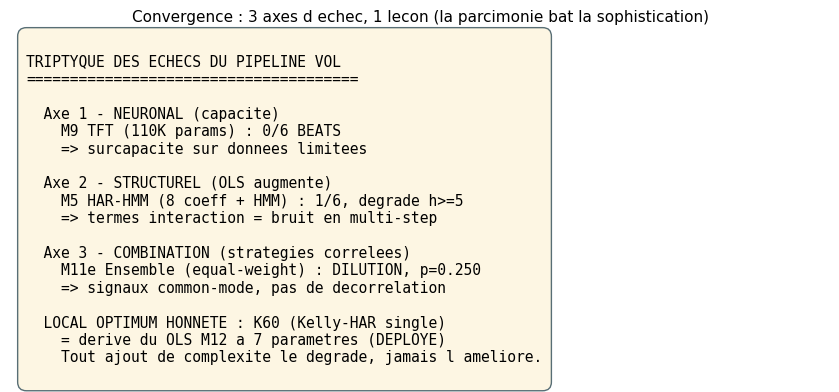

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.axis('off')
txt = '''
TRIPTYQUE DES ECHECS DU PIPELINE VOL
======================================

  Axe 1 - NEURONAL (capacite)
    M9 TFT (110K params) : 0/6 BEATS
    => surcapacite sur donnees limitees

  Axe 2 - STRUCTUREL (OLS augmente)
    M5 HAR-HMM (8 coeff + HMM) : 1/6, degrade h>=5
    => termes interaction = bruit en multi-step

  Axe 3 - COMBINATION (strategies correlees)
    M11e Ensemble (equal-weight) : DILUTION, p=0.250
    => signaux common-mode, pas de decorrelation

  LOCAL OPTIMUM HONNETE : K60 (Kelly-HAR single)
    = derive du OLS M12 a 7 parametres (DEPLOYE)
    Tout ajout de complexite le degrade, jamais l ameliore.
'''
ax.text(0.02, 0.98, txt, transform=ax.transAxes, fontsize=10.5,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#fdf6e3', edgecolor='#586e75'))
ax.set_title('Convergence : 3 axes d echec, 1 lecon (la parcimonie bat la sophistication)', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Lecon : ne pas confondre ensemble et diversification

L'echec de M11e est pedagogiquement important car il contredit un reflexe standard du ML.
En classification (random forest, gradient boosting), un ensemble de modeles faibles
bat le meilleur seul -- **conditionnellement a leur decorrelation**. Transposer ce reflexe
au trading sans verifier la decorrelation est un piege classique de la litterature finance :

1. **Decorrelation absente** : les 3 strategies HAR-Kelly prennent toutes des positions
   long-only vol-scaling. Leurs poids sont fortement correles (meme direction de reaction
   a la volatilite). L'ensemble n'est pas un portefeuille diversifie, c'est une moyenne
   d'un signal common-mode -- mecaniquement tire vers le plus faible.
2. **K60 deja optimal** : M11a/b/c ont identifie K60 comme dominante (27/35 raw BEATS).
   Moyenner avec des composantes systematiquement plus faibles ne peut que diluer, pas
   amplifier. Il faudrait une composante **orthogonale** (momentum equity, carry FX) pour
   ajouter de l'edge -- hors-scope de ce panel crypto.
3. **Le label script 'HELPS' est un faux positif statistique** : median>0 sans
   significativite (p=0.250, 0/35 p<0.05). C'est l'illustration que **un verdict automatique
   se valide par son test statistique, pas par son label** (G.1).

### Le fil rouge consolide du pipeline vol

Six notebooks de recherche couvrent maintenant toute la courbe d'expressivite et les trois
axes de sophistication testes. La conclusion est univoque et robuste : sur ce benchmark
crypto a donnees limitees, **la parcimonie bat l'expressivite neuronale (M9), la sophistication
structurelle (M5) ET la suragregation de signaux correles (M11e)**. Le modele OLS a 7
parametres (M12 HAR-RV-J Kelly) reste le seul deploye en production. C'est le fil conducteur
le plus robuste de toute la serie vol.

### Hypotheses ouvertes (a tester si futur cycle ML)

- **Stacking meta-learner OOS** (regression logistique sur features de marche -> poids
  dynamiques entre K60/K30/VTH) -- apprendre l'aggregation au lieu de la moyenner.
- **Cross-asset ensemble** (K60 crypto + momentum equity + carry FX) -- decorrelation
  reelle entre classes d'actifs.
- **Regime-conditional ensemble** (K60 en haut-vol, K30 en bas-vol) -- hypothese
  speculative, a confronter aux donnees.

### References

- Ledoit, O. & Wolf, M. (2008). *Robust Performance Hypothesis Testing with the Sharpe
  Ratio*. Journal of Empirical Finance 15(5). (Le test paired Sharpe-diff HAC utilise).
- Corsi, F. (2009). *A Simple Approximate Long-Memory Model of Realized Volatility*. (HAR).
- Pour les 3 axes paralleles d'echec : [M9 TFT](m9_tft_vol_research.ipynb)
  (neuronal), [M5 HMM-regime](m5_hmm_regime_research.ipynb) (structurel).
- Pour le modele deploye : [M12 HAR-RV-J](m12_har_rv_j_research.ipynb).
- Fiche technique complete : [`docs/M11e_ENSEMBLE.md`](docs/M11e_ENSEMBLE.md).